## 1. Import Libraries

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import eda_helper_functions
from sklearn.ensemble import IsolationForest

## 2. Read the Training Data

In [2]:
file_path = r"../data/train.csv"

train = pd.read_csv(file_path)

train

,airline,date_of_journey,source,destination,dep_time,arrival_time,duration,total_stops,additional_info,price
0,Jet Airways,2019-03-21,Banglore,Delhi,08:55:00,19:10:00,615,1.0,In-flight meal not included,7832
1,Jet Airways,2019-03-27,Delhi,Cochin,17:30:00,04:25:00,655,1.0,In-flight meal not included,6540
2,Goair,2019-03-09,Banglore,Delhi,11:40:00,14:35:00,175,0.0,No Info,7305
3,Air India,2019-06-12,Kolkata,Banglore,09:25:00,18:30:00,545,1.0,No Info,8366
4,Jet Airways,2019-03-12,Banglore,Delhi,22:55:00,07:40:00,525,1.0,In-flight meal not included,11087
...,...,...,...,...,...,...,...,...,...,...
6690,Jet Airways,2019-03-21,Delhi,Cochin,10:45:00,18:50:00,1925,2.0,No Info,11093
6691,Air India,2019-05-01,Kolkata,Banglore,09:25:00,18:30:00,545,1.0,No Info,8891
6692,Jet Airways,2019-06-01,Delhi,Cochin,14:00:00,19:00:00,300,1.0,In-flight meal not included,10262
6693,Air Asia,2019-06-24,Delhi,Cochin,07:55:00,13:25:00,330,1.0,No Info,6152


In [3]:
train.dtypes

airline                str
date_of_journey        str
source                 str
destination            str
dep_time               str
arrival_time           str
duration             int64
total_stops        float64
additional_info        str
price                int64
dtype: object

### 2.1 Fixing Data Types

In [12]:
train = train.assign(**{
    col: pd.to_datetime(train.loc[:, col], format="mixed")
    for col in ["date_of_journey", "dep_time", "arrival_time"]
})

train.dtypes

airline                       str
date_of_journey    datetime64[us]
source                        str
destination                   str
dep_time           datetime64[us]
arrival_time       datetime64[us]
duration                    int64
total_stops               float64
additional_info               str
price                       int64
dtype: object

In [13]:
train

,airline,date_of_journey,source,destination,dep_time,arrival_time,duration,total_stops,additional_info,price
0,Jet Airways,2019-03-21,Banglore,Delhi,2026-03-06 08:55:00,2026-03-06 19:10:00,615,1.0,In-flight meal not included,7832
1,Jet Airways,2019-03-27,Delhi,Cochin,2026-03-06 17:30:00,2026-03-06 04:25:00,655,1.0,In-flight meal not included,6540
2,Goair,2019-03-09,Banglore,Delhi,2026-03-06 11:40:00,2026-03-06 14:35:00,175,0.0,No Info,7305
3,Air India,2019-06-12,Kolkata,Banglore,2026-03-06 09:25:00,2026-03-06 18:30:00,545,1.0,No Info,8366
4,Jet Airways,2019-03-12,Banglore,Delhi,2026-03-06 22:55:00,2026-03-06 07:40:00,525,1.0,In-flight meal not included,11087
...,...,...,...,...,...,...,...,...,...,...
6690,Jet Airways,2019-03-21,Delhi,Cochin,2026-03-06 10:45:00,2026-03-06 18:50:00,1925,2.0,No Info,11093
6691,Air India,2019-05-01,Kolkata,Banglore,2026-03-06 09:25:00,2026-03-06 18:30:00,545,1.0,No Info,8891
6692,Jet Airways,2019-06-01,Delhi,Cochin,2026-03-06 14:00:00,2026-03-06 19:00:00,300,1.0,In-flight meal not included,10262
6693,Air Asia,2019-06-24,Delhi,Cochin,2026-03-06 07:55:00,2026-03-06 13:25:00,330,1.0,No Info,6152


## 3. High-level Summary of Data

In [14]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 6695 entries, 0 to 6694
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   airline          6695 non-null   str           
 1   date_of_journey  6695 non-null   datetime64[us]
 2   source           6695 non-null   str           
 3   destination      6695 non-null   str           
 4   dep_time         6695 non-null   datetime64[us]
 5   arrival_time     6695 non-null   datetime64[us]
 6   duration         6695 non-null   int64         
 7   total_stops      6694 non-null   float64       
 8   additional_info  6695 non-null   str           
 9   price            6695 non-null   int64         
dtypes: datetime64[us](3), float64(1), int64(2), str(4)
memory usage: 523.2 KB


In [17]:
train.describe(include="number")

,duration,total_stops,price
count,6695.000000,6694.000000,6695.000000
mean,633.489171,0.801464,9030.965646
std,503.006311,0.659737,4639.522857
min,75.000000,0.000000,1759.000000
25%,170.000000,0.000000,5224.000000
50%,510.000000,1.000000,8283.000000
75%,922.500000,1.000000,12373.000000
max,2860.000000,3.000000,62427.000000


In [28]:
(
    train.assign(
        total_stops = train.total_stops.astype('str')
    )
    .describe(include='str')
)

,airline,source,destination,total_stops,additional_info
count,6695,6695,6695,6694,6695
unique,9,5,5,4,7
top,Jet Airways,Delhi,Cochin,1.0,No Info
freq,2391,2730,2730,3580,5249


## 4. High-level analysis of Missing Values

In [29]:
eda_helper_functions.missing_info(train)

,count,percentage
variable,,
total_stops,1,0.014937


## 5. High-level analysis of Outliers

In [34]:
forest = IsolationForest(n_estimators=10, random_state=42)

In [ ]:
(
    train
    .assign(outlier=forest.fit_predict(
        train
        .drop(columns="price")
        .select_dtypes(include="number")
    ))
    .query("outlier == -1")
    #.duration
    #.describe()
)

,airline,date_of_journey,source,destination,dep_time,arrival_time,duration,total_stops,additional_info,price,outlier
5,Jet Airways,2019-04-21,Banglore,Delhi,2026-03-06 18:55:00,2026-03-06 22:00:00,185,0.0,In-flight meal not included,4544,-1
7,Spicejet,2019-06-15,Mumbai,Hyderabad,2026-03-06 05:45:00,2026-03-06 07:15:00,90,0.0,No check-in baggage included,2647,-1
9,Jet Airways,2019-05-09,Delhi,Cochin,2026-03-06 23:05:00,2026-03-06 04:25:00,1760,2.0,No Info,15129,-1
10,Jet Airways,2019-06-12,Kolkata,Banglore,2026-03-06 14:05:00,2026-03-06 10:05:00,1200,1.0,No Info,13044,-1
12,Jet Airways,2019-06-24,Delhi,Cochin,2026-03-06 21:25:00,2026-03-06 19:00:00,1295,2.0,No Info,13292,-1
...,...,...,...,...,...,...,...,...,...,...,...
6687,Air India,2019-06-06,Kolkata,Banglore,2026-03-06 05:50:00,2026-03-06 08:55:00,1625,2.0,No Info,12723,-1
6688,Jet Airways,2019-06-15,Delhi,Cochin,2026-03-06 21:25:00,2026-03-06 12:35:00,910,2.0,In-flight meal not included,9905,-1
6689,Indigo,2019-03-03,Mumbai,Hyderabad,2026-03-06 09:10:00,2026-03-06 10:40:00,90,0.0,No Info,5755,-1
6690,Jet Airways,2019-03-21,Delhi,Cochin,2026-03-06 10:45:00,2026-03-06 18:50:00,1925,2.0,No Info,11093,-1


## 6. Pair Plots

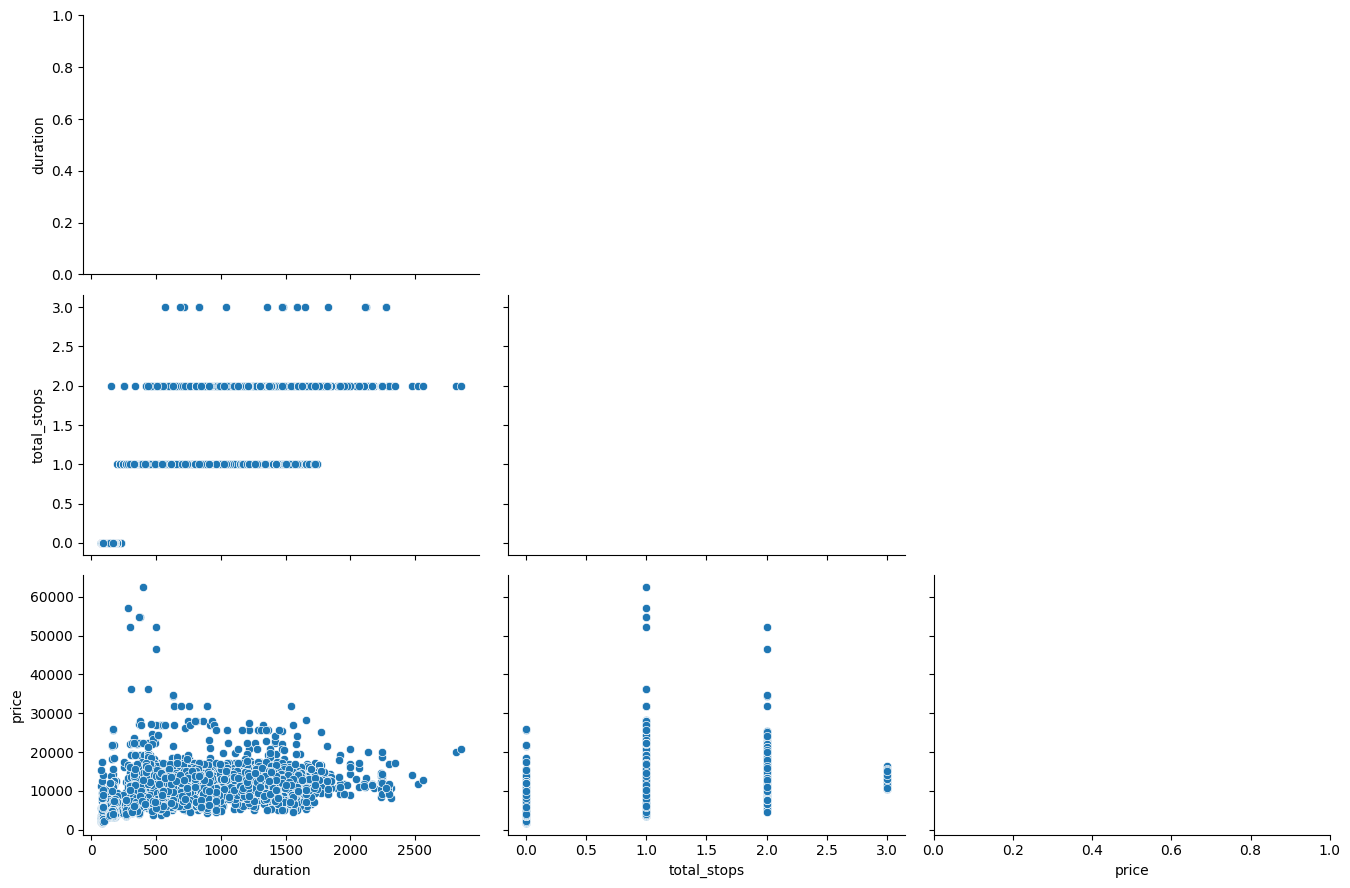

In [36]:
eda_helper_functions.pair_plots(train)

## 7. Correlation Analysis 

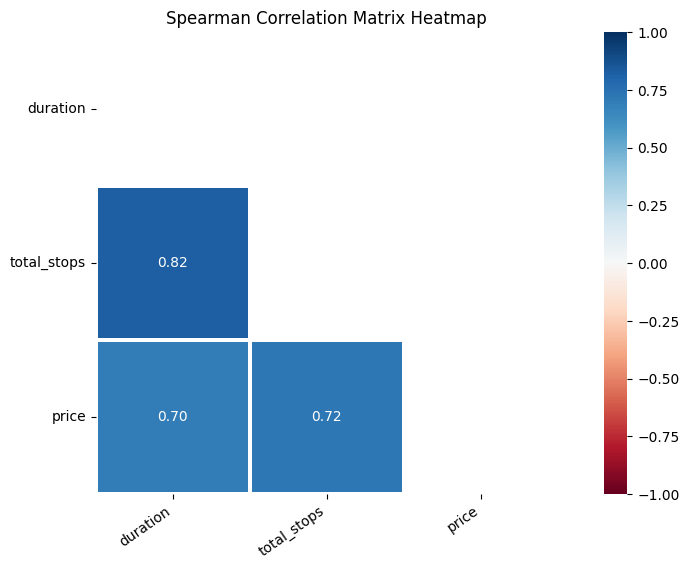

In [37]:
eda_helper_functions.correlation_heatmap(train)

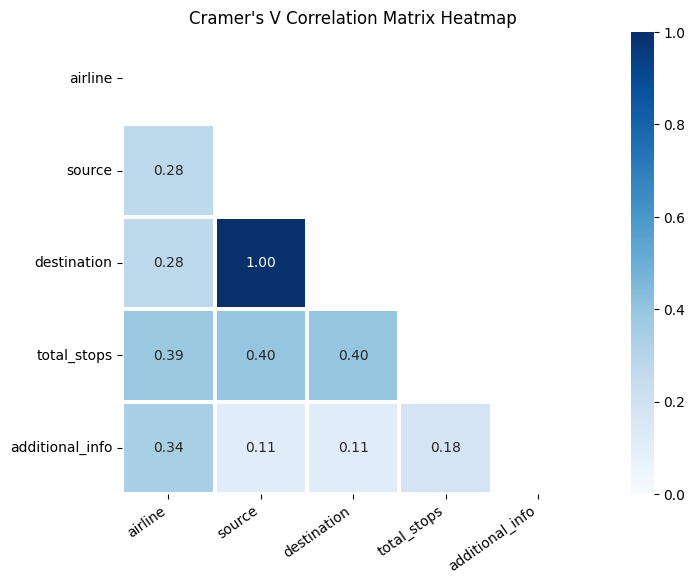

In [39]:
eda_helper_functions.cramersV_heatmap(train.assign(total_stops=train.total_stops.astype('str')))

## 8. Detailed Analysis

In [40]:
train.columns

Index(['airline', 'date_of_journey', 'source', 'destination', 'dep_time',
       'arrival_time', 'duration', 'total_stops', 'additional_info', 'price'],
      dtype='str')

### 8.1 airline

In [41]:
train.airline

0       Jet Airways
1       Jet Airways
2             Goair
3         Air India
4       Jet Airways
           ...     
6690    Jet Airways
6691      Air India
6692    Jet Airways
6693       Air Asia
6694      Air India
Name: airline, Length: 6695, dtype: str

In [42]:
eda_helper_functions.cat_summary(train, "airline")

0       Jet Airways
1       Jet Airways
2             Goair
3         Air India
4       Jet Airways
           ...     
6690    Jet Airways
6691      Air India
6692    Jet Airways
6693       Air Asia
6694      Air India
Name: airline, Length: 6695, dtype: str

Data Type      : str
Cardinality    : 9 categories
Missing Data   : 0 rows (0.00 %)
Available Data : 6,695 / 6,695 rows


,
count,6695
unique,9
top,Jet Airways
freq,2391


,count,percentage
category,,
Jet Airways,2391,0.357132
Indigo,1296,0.193577
Air India,1076,0.160717
Multiple Carriers,736,0.109933
Spicejet,537,0.080209
Vistara,322,0.048096
Air Asia,211,0.031516
Goair,125,0.018671
Trujet,1,0.000149


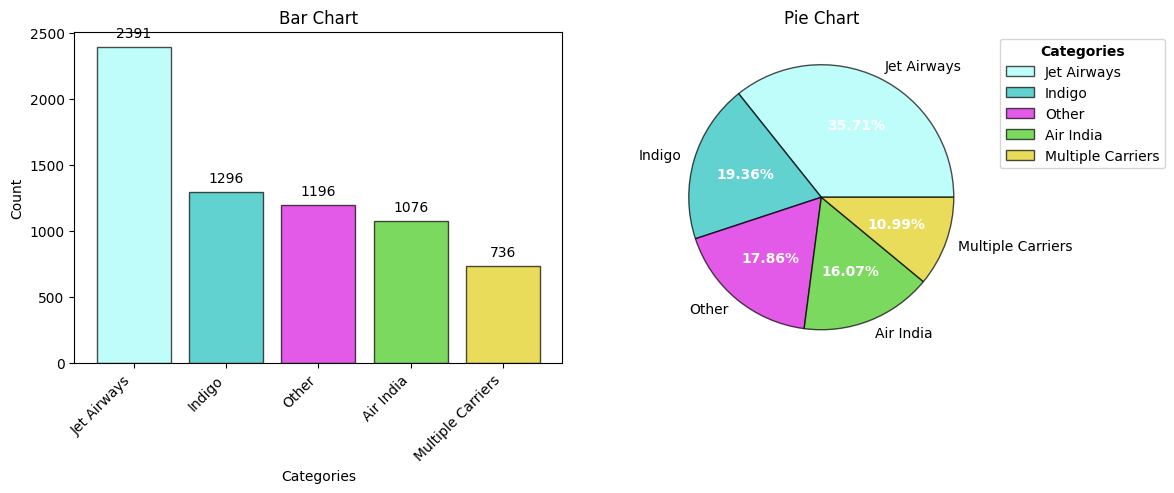

In [45]:
eda_helper_functions.cat_univar_plots(train, "airline", show_wordcloud=False, k=4)

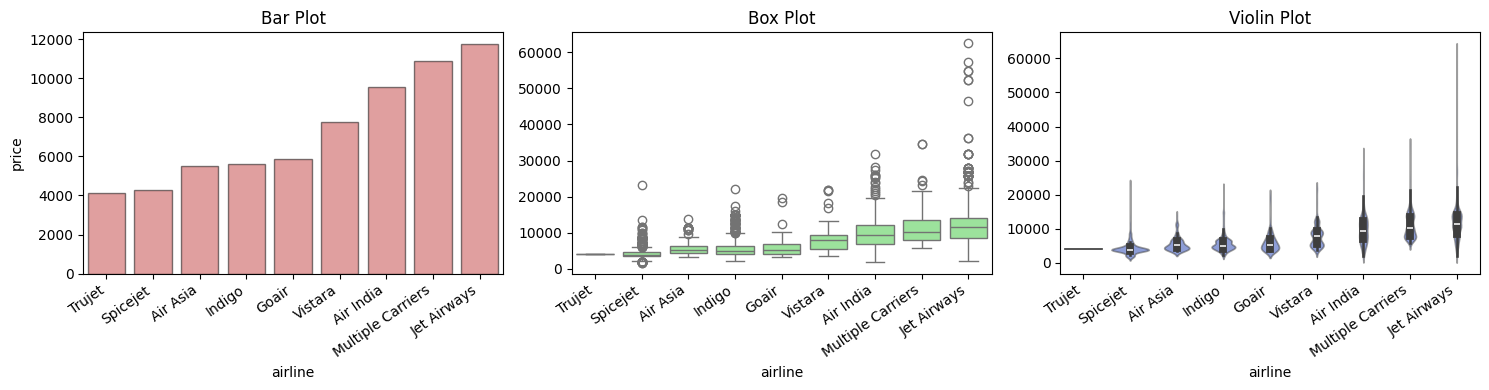

In [46]:
eda_helper_functions.num_cat_bivar_plots(
    data=train,
    num_var="price",
    cat_var="airline"
)

In [47]:
eda_helper_functions.num_cat_hyp_testing(train, "price", "airline")

- Significance Level   : 5.0%
- Null Hypothesis      : The groups have similar population mean
- Alternate Hypothesis : The groups don't have similar population mean
- Test Statistic       : 473.280702706463
- p-value              : 0.0
- Since p-value is less than 0.05, we Reject the Null Hypothesis at 5.0% significance level
- CONCLUSION: The variables price and airline are associated to each other


- Significance Level   : 5.0%
- Null Hypothesis      : The groups have similar population median
- Alternate Hypothesis : The groups don't have similar population median
- Test Statistic       : 3131.4120748217883
- p-value              : 0.0
- Since p-value is less than 0.05, we Reject the Null Hypothesis at 5.0% significance level
- CONCLUSION: The variables price and airline are associated to each other


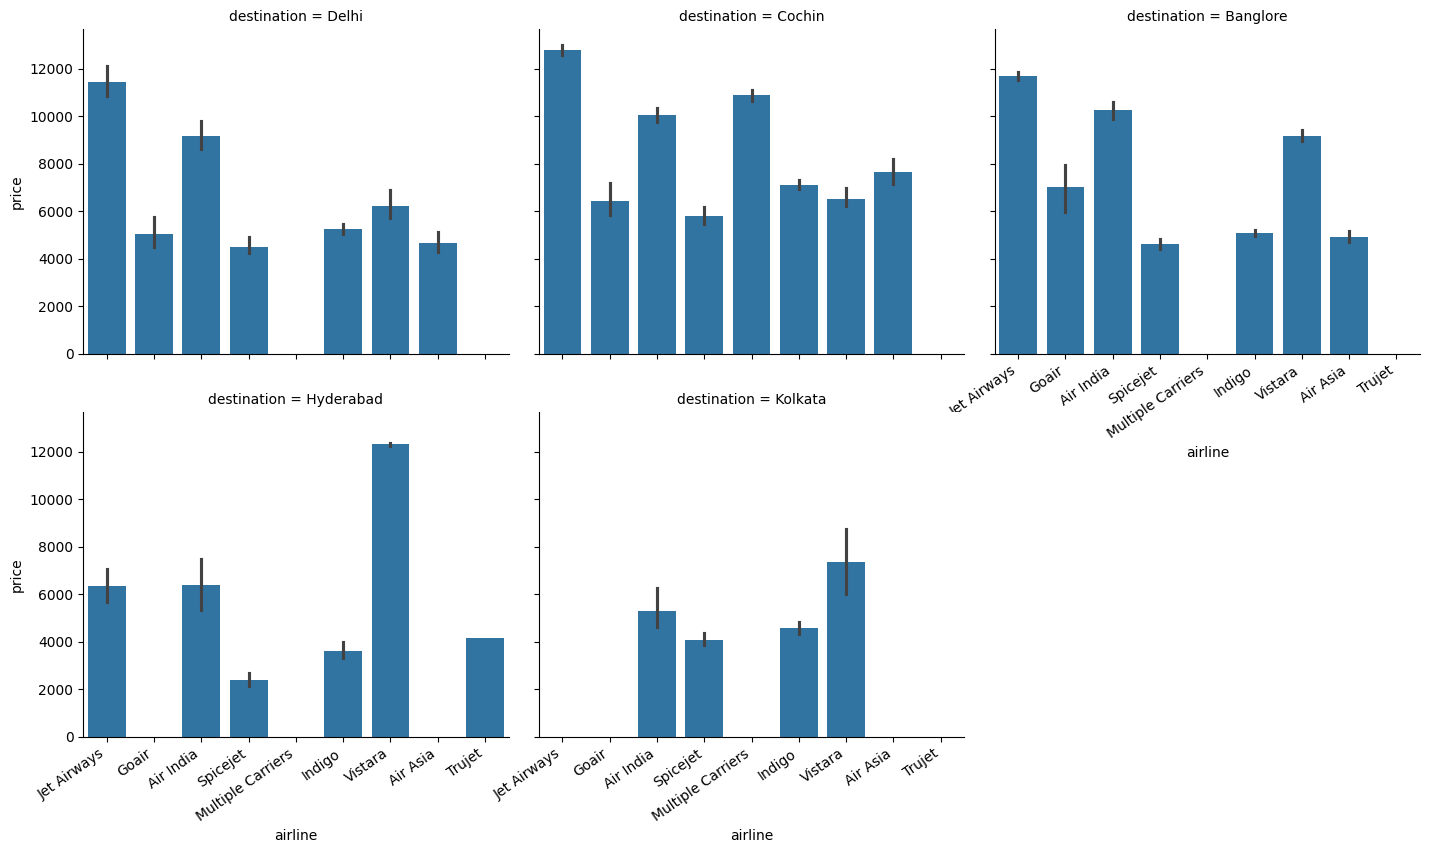

In [54]:
airline_grid = sns.FacetGrid(
    data=train,
    col="destination",
    col_wrap=3,
    height=4,
    aspect=1.2,
    sharey=True
)

airline_grid.map(sns.barplot, "airline", "price", order=train.airline.unique())

for ax in airline_grid.axes[2:]:
    eda_helper_functions.rotate_xlabels(ax)

### 8.2 date_of_journey

In [55]:
train.date_of_journey

0      2019-03-21
1      2019-03-27
2      2019-03-09
3      2019-06-12
4      2019-03-12
          ...    
6690   2019-03-21
6691   2019-05-01
6692   2019-06-01
6693   2019-06-24
6694   2019-03-01
Name: date_of_journey, Length: 6695, dtype: datetime64[us]

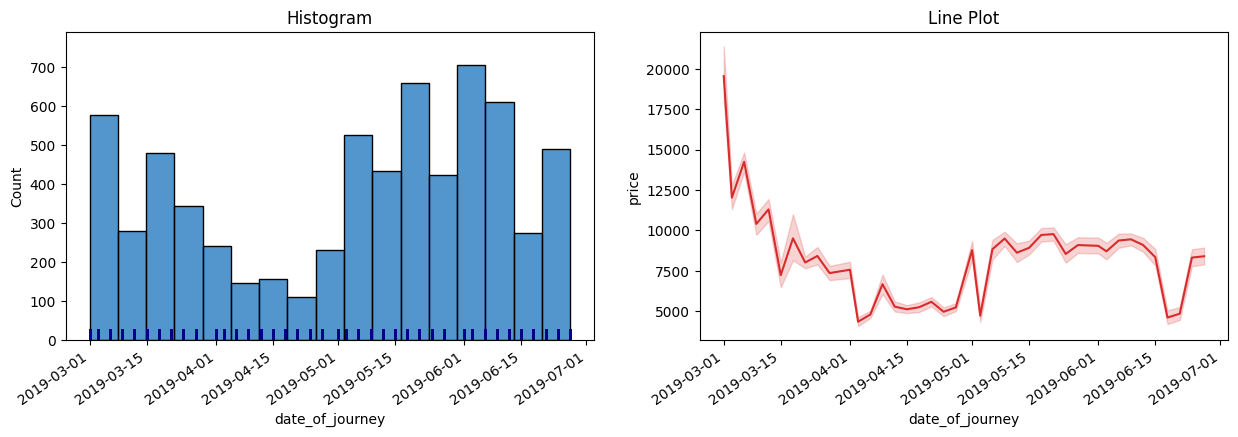

In [56]:
eda_helper_functions.dt_univar_plots(train, "date_of_journey", "price")

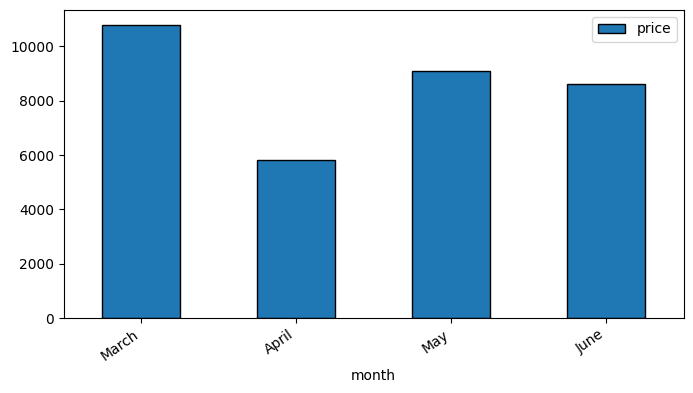

In [63]:
(
    train
    .groupby(pd.Grouper(key="date_of_journey", freq="ME"))
    .price.mean()
    .to_frame()
    .set_axis(["March","April","May","June"])
    .rename_axis(index="month")
    .plot(
        kind="bar",
        figsize=(8, 4),
        edgecolor="black"
    )
)

ax = plt.gca()
eda_helper_functions.rotate_xlabels(ax)

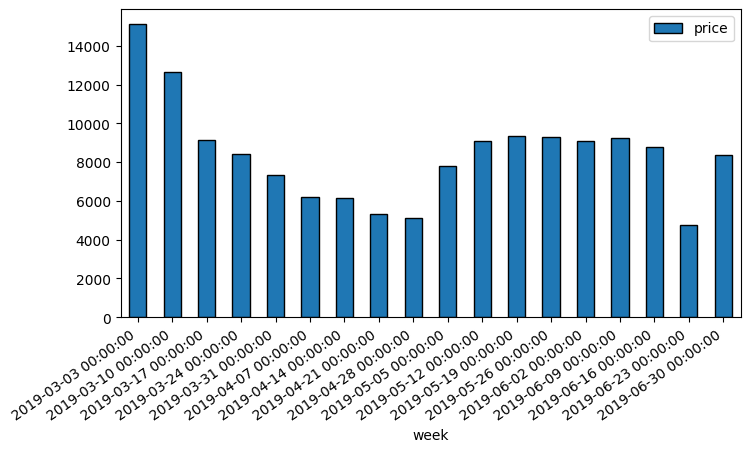

In [64]:
(
    train
    .groupby(pd.Grouper(key="date_of_journey", freq="W"))
    .price.mean()
    .to_frame()
    .rename_axis(index="week")
    .plot(
        kind="bar",
        figsize=(8, 4),
        edgecolor="black"
    )
)

ax = plt.gca()
eda_helper_functions.rotate_xlabels(ax)

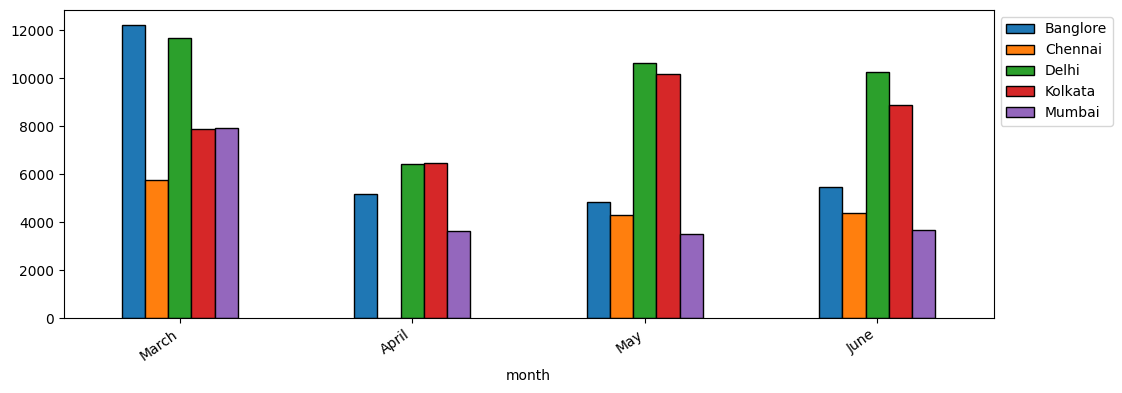

In [79]:
(
    train
    .groupby([pd.Grouper(key="date_of_journey", freq="ME"), "source"])
    .price.mean()
    .unstack(fill_value=0)
    .set_axis(["March","April","May","June"])
    .rename_axis(index="month")
    .plot(
        kind="bar",
        figsize=(12, 4),
        edgecolor="black",
    )
)

ax = plt.gca()

ax.legend(
    loc="upper left",
    bbox_to_anchor=(1,1)
)
eda_helper_functions.rotate_xlabels(ax)

### 8.3 dep_time

In [80]:
train.dep_time

0      2026-03-06 08:55:00
1      2026-03-06 17:30:00
2      2026-03-06 11:40:00
3      2026-03-06 09:25:00
4      2026-03-06 22:55:00
               ...        
6690   2026-03-06 10:45:00
6691   2026-03-06 09:25:00
6692   2026-03-06 14:00:00
6693   2026-03-06 07:55:00
6694   2026-03-06 11:50:00
Name: dep_time, Length: 6695, dtype: datetime64[us]

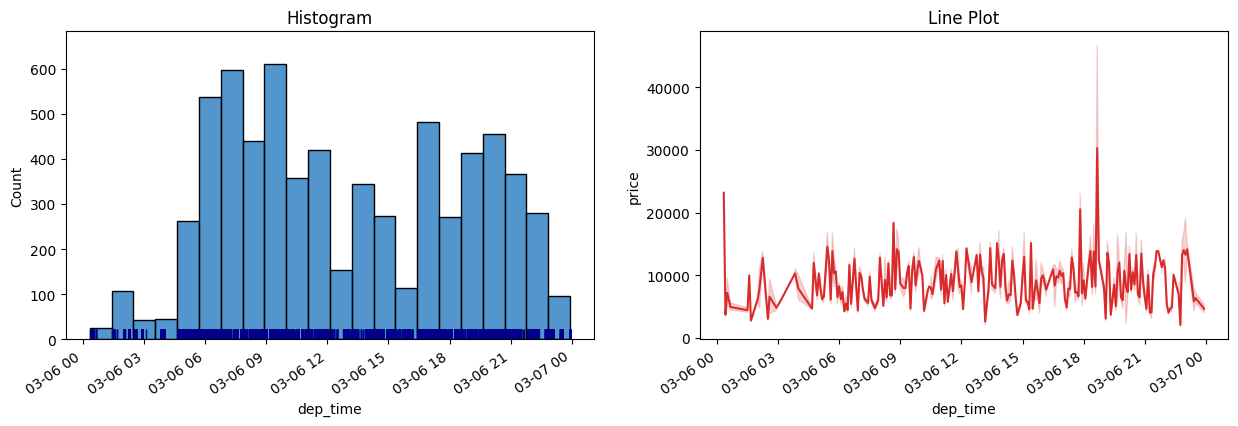

In [81]:
eda_helper_functions.dt_univar_plots(train, "dep_time", "price")

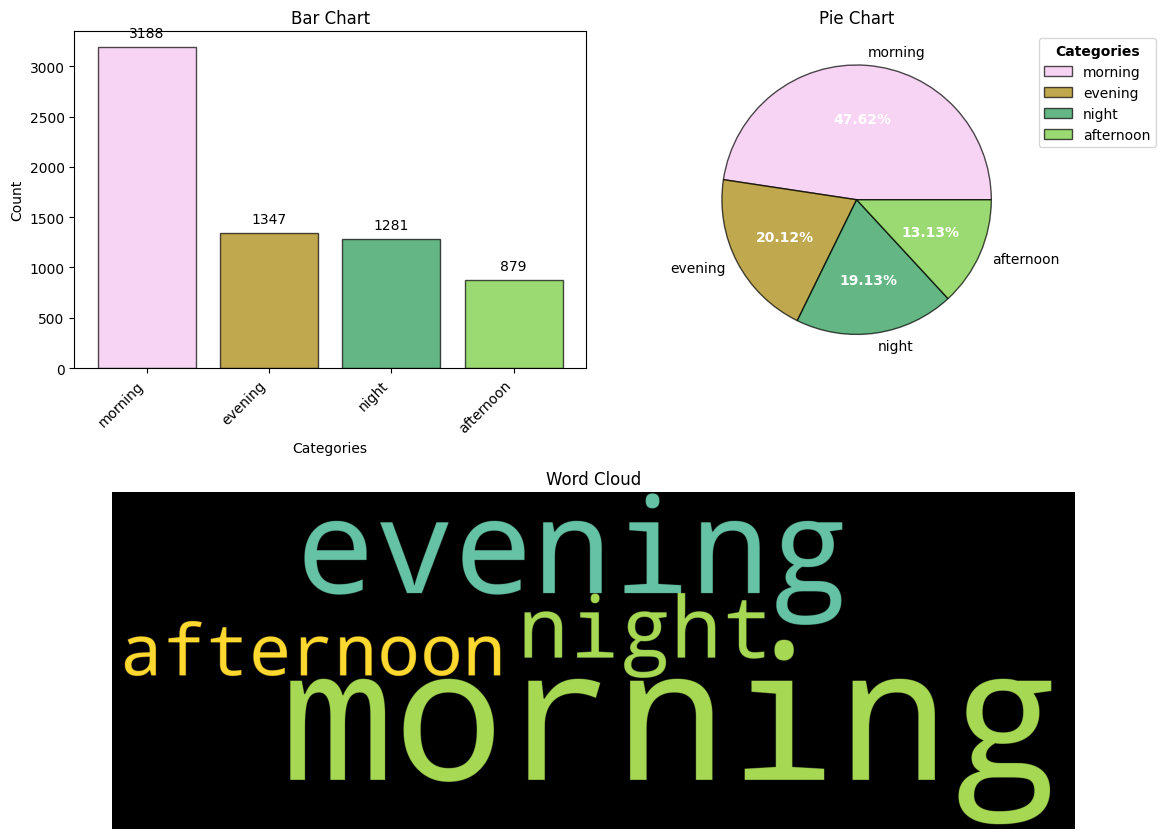

In [87]:
(
    train
    .assign(
        dep_time = lambda df_: (
            np.select(
                [df_.dep_time.dt.hour.between(4,12, inclusive="left"),
                df_.dep_time.dt.hour.between(12,16, inclusive="left"),
                df_.dep_time.dt.hour.between(16,20, inclusive="left")],
                ["morning", "afternoon", "evening"],
                default="night")
            )
    )
    .pipe(eda_helper_functions.cat_univar_plots, "dep_time")
)

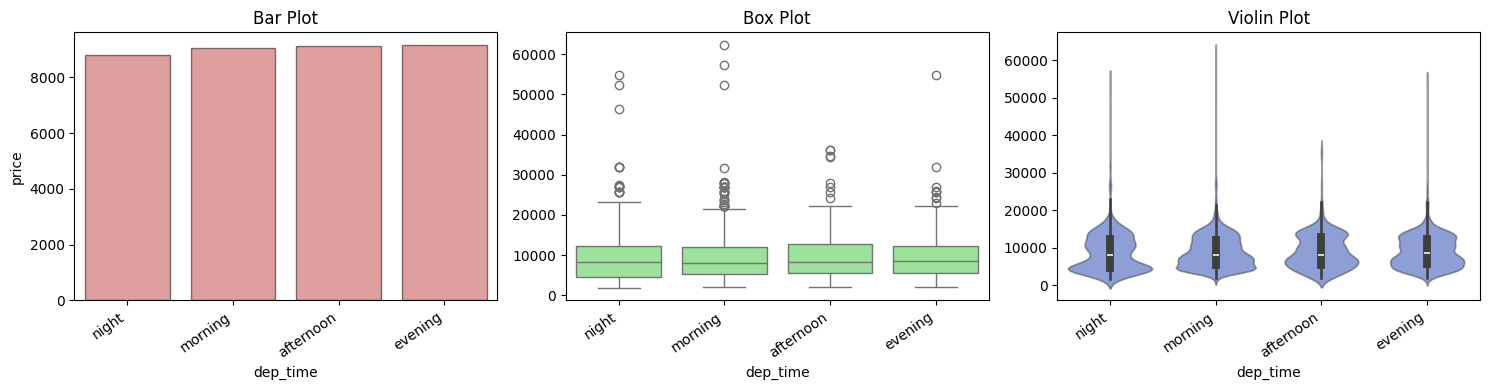

In [88]:
(
    train
    .assign(
        dep_time = lambda df_: (
            np.select(
                [df_.dep_time.dt.hour.between(4,12, inclusive="left"),
                df_.dep_time.dt.hour.between(12,16, inclusive="left"),
                df_.dep_time.dt.hour.between(16,20, inclusive="left")],
                ["morning", "afternoon", "evening"],
                default="night")
            )
    )
    .pipe(eda_helper_functions.num_cat_bivar_plots, "price", "dep_time")
)

### 8.4 duration

In [89]:
train.duration

0        615
1        655
2        175
3        545
4        525
        ... 
6690    1925
6691     545
6692     300
6693     330
6694    1265
Name: duration, Length: 6695, dtype: int64

In [90]:
eda_helper_functions.num_summary(train, "duration")

0        615
1        655
2        175
3        545
4        525
        ... 
6690    1925
6691     545
6692     300
6693     330
6694    1265
Name: duration, Length: 6695, dtype: int64

Data Type      : int64
Missing Data   : 0 rows (0.00 %)
Available Data : 6,695 / 6,695 rows


,value
percentile,
0,75.0
5,90.0
10,145.0
25,170.0
50,510.0
75,922.5
90,1440.0
95,1601.5
99,1855.0


,value
mean,633.489171
trimmed mean (5%),599.711299
trimmed mean (10%),571.053761
median,510.000000


,value
var,253015.348516
std,503.006311
IQR,752.500000
mad,340.000000
coef_variance,0.794025


,value
skewness,0.893578
kurtosis,-0.053860


Significance Level   : 0.05
Null Hypothesis      : The data is normally distributed
Alternate Hypothesis : The data is not normally distributed
p-value              : 7.39934424543729e-57
Test Statistic       : 0.8865693123370929
- Since p-value is less than alpha (0.05), we Reject the Null Hypothesis at 5.0% significance level
- CONCLUSION: We conclude that the data sample is not normally distributed


Significance Level   : 0.05
Null Hypothesis      : The data is normally distributed
Alternate Hypothesis : The data is not normally distributed
Critical Value       : 0.752
Test Statistic       : 248.46369663341648
- Since the Test-statistic is greater than Critical Value, we Reject the Null Hypothesis at 5.0% significance level
- CONCLUSION: We conclude that the data sample is not normally distributed


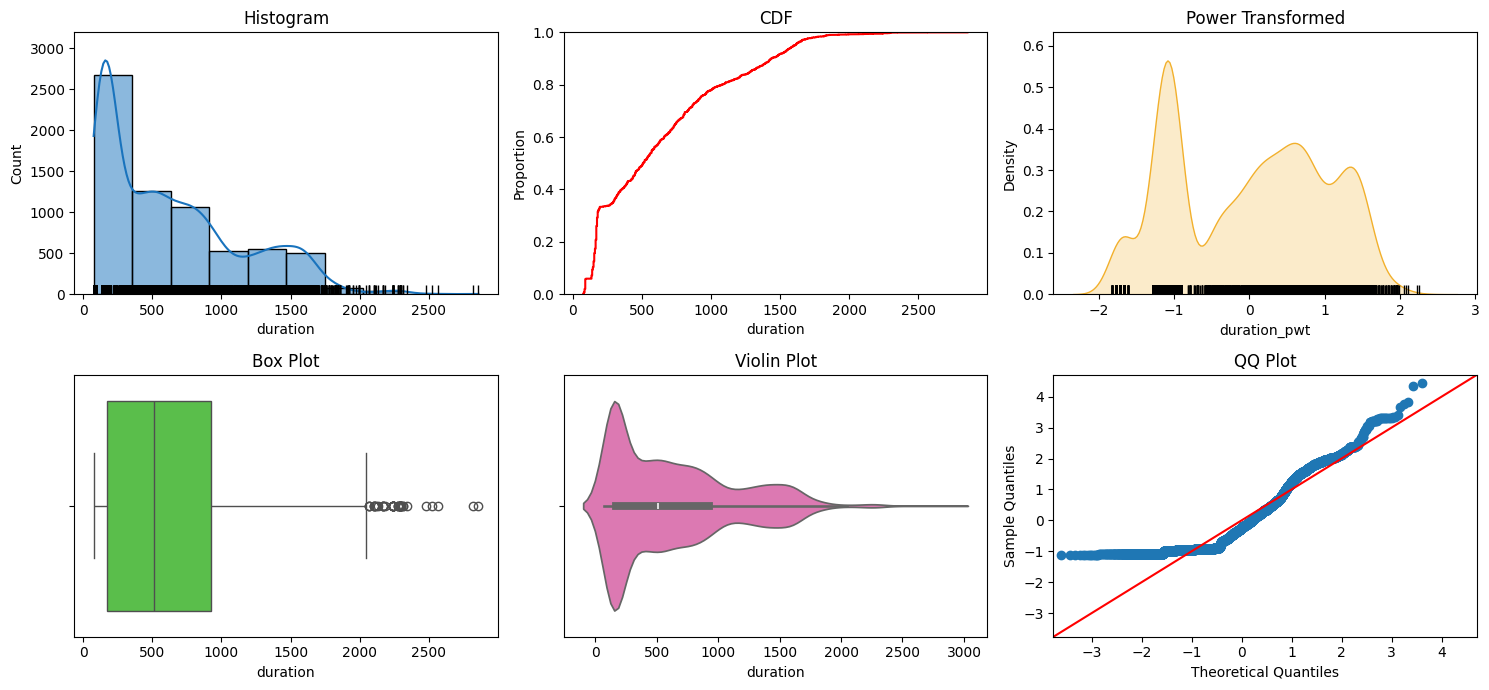

In [91]:
eda_helper_functions.num_univar_plots(train, "duration")

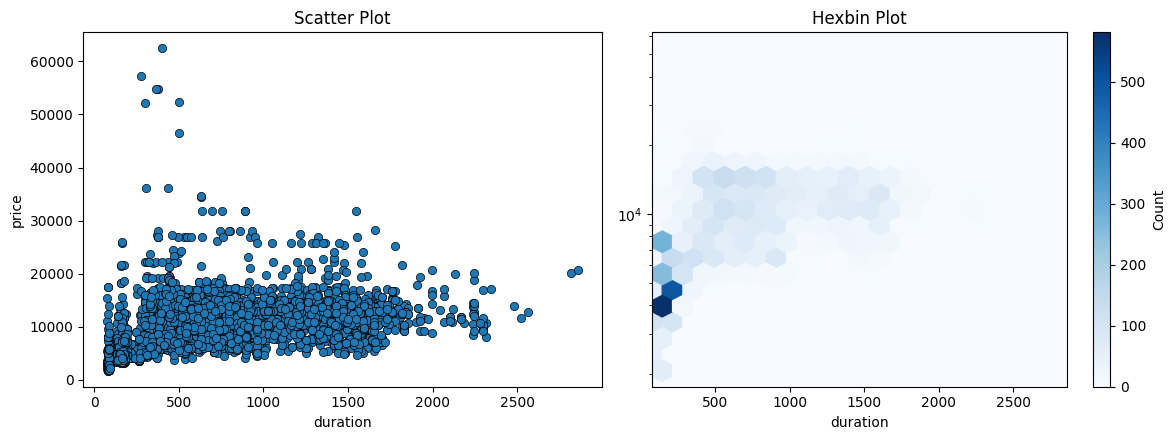

In [97]:
eda_helper_functions.num_bivar_plots(
    train,
    "duration",
    "price",
    hexbin_kwargs=dict(
        yscale="log",
        gridsize=20,
        cmap="Blues"
    )
)

In [98]:
eda_helper_functions.num_num_hyp_testing(train, "duration", "price")

- Significance Level   : 5.0%
- Null Hypothesis      : The samples are uncorrelated
- Alternate Hypothesis : The samples are correlated
- Test Statistic       : 0.509012449177902
- p-value              : 0.0
- Since p-value is less than 0.05, we Reject the Null Hypothesis at 5.0% significance level
- CONCLUSION: The variables duration and price are correlated


- Significance Level   : 5.0%
- Null Hypothesis      : The samples are uncorrelated
- Alternate Hypothesis : The samples are correlated
- Test Statistic       : 0.6978600816697789
- p-value              : 0.0
- Since p-value is less than 0.05, we Reject the Null Hypothesis at 5.0% significance level
- CONCLUSION: The variables duration and price are correlated


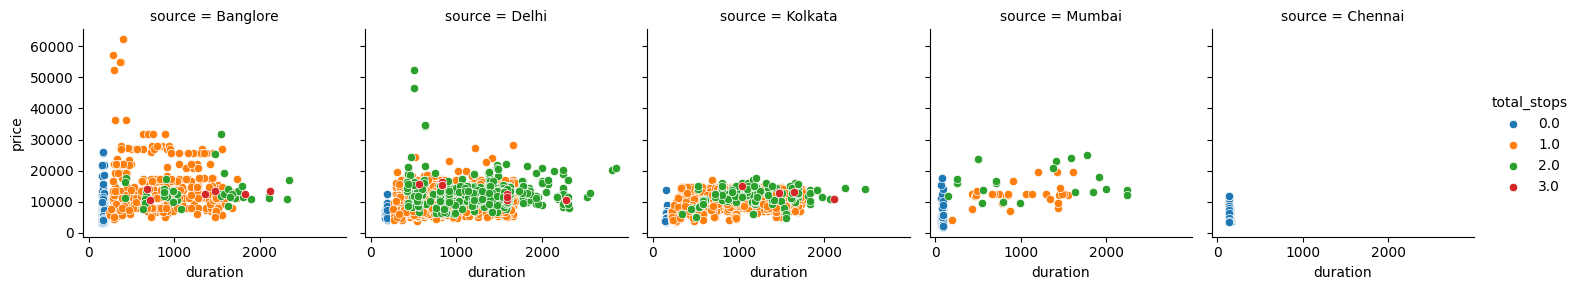

In [ ]:
duration_grid = sns.FacetGrid(
    data=train,
    col="source",
    #row=
    hue="total_stops",
    sharey=True
)

duration_grid.map(sns.scatterplot, "duration", "price")

duration_grid.add_legend()

In [101]:
eda_helper_functions.get_iqr_outliers(train, "duration")

Lower Limit : -958.75
Upper Limit : 2051.25


,airline,date_of_journey,source,destination,dep_time,arrival_time,duration,total_stops,additional_info,price
3690,Air India,2019-05-01,Kolkata,Banglore,2026-03-06 05:50:00,2026-03-06 16:15:00,2065,2.0,No Info,10991
3225,Jet Airways,2019-03-06,Delhi,Cochin,2026-03-06 17:55:00,2026-03-06 04:25:00,2070,2.0,In-flight meal not included,15812
6079,Jet Airways,2019-03-06,Delhi,Cochin,2026-03-06 17:55:00,2026-03-06 04:25:00,2070,2.0,No Info,17072
1517,Air India,2019-03-03,Banglore,Delhi,2026-03-06 11:05:00,2026-03-06 22:10:00,2105,2.0,No Info,11948
4589,Air India,2019-03-18,Banglore,Delhi,2026-03-06 11:05:00,2026-03-06 22:10:00,2105,2.0,No Info,11161
2990,Air India,2019-03-03,Banglore,Delhi,2026-03-06 11:05:00,2026-03-06 22:10:00,2105,2.0,No Info,11791
2916,Air India,2019-05-12,Kolkata,Banglore,2026-03-06 12:00:00,2026-03-06 23:15:00,2115,3.0,No Info,10991
2170,Air India,2019-03-12,Banglore,Delhi,2026-03-06 06:45:00,2026-03-06 18:05:00,2120,3.0,No Info,13387
1105,Jet Airways,2019-03-06,Delhi,Cochin,2026-03-06 16:50:00,2026-03-06 04:25:00,2135,2.0,No Info,19907
3091,Air India,2019-03-03,Delhi,Cochin,2026-03-06 07:05:00,2026-03-06 19:15:00,2170,2.0,No Info,11762


### 8.5 additional_info

In [102]:
eda_helper_functions.cat_summary(train, "additional_info")

0       In-flight meal not included
1       In-flight meal not included
2                           No Info
3                           No Info
4       In-flight meal not included
                   ...             
6690                        No Info
6691                        No Info
6692    In-flight meal not included
6693                        No Info
6694                 1 Long layover
Name: additional_info, Length: 6695, dtype: str

Data Type      : str
Cardinality    : 7 categories
Missing Data   : 0 rows (0.00 %)
Available Data : 6,695 / 6,695 rows


,
count,6695
unique,7
top,No Info
freq,5249


,count,percentage
category,,
No Info,5249,0.784018
In-flight meal not included,1215,0.181479
No check-in baggage included,207,0.030919
1 Long layover,16,0.002390
Change airports,5,0.000747
Business class,2,0.000299
Red-eye flight,1,0.000149


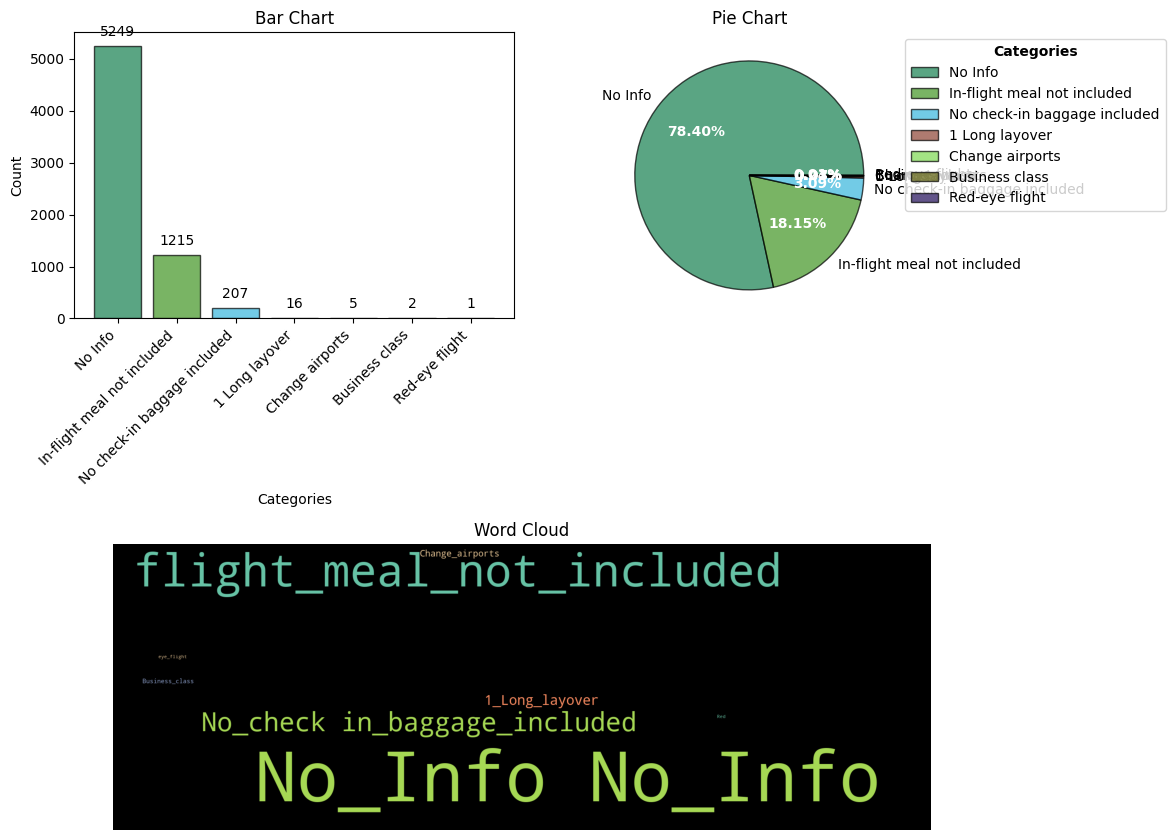

In [103]:
eda_helper_functions.cat_univar_plots(train, "additional_info")

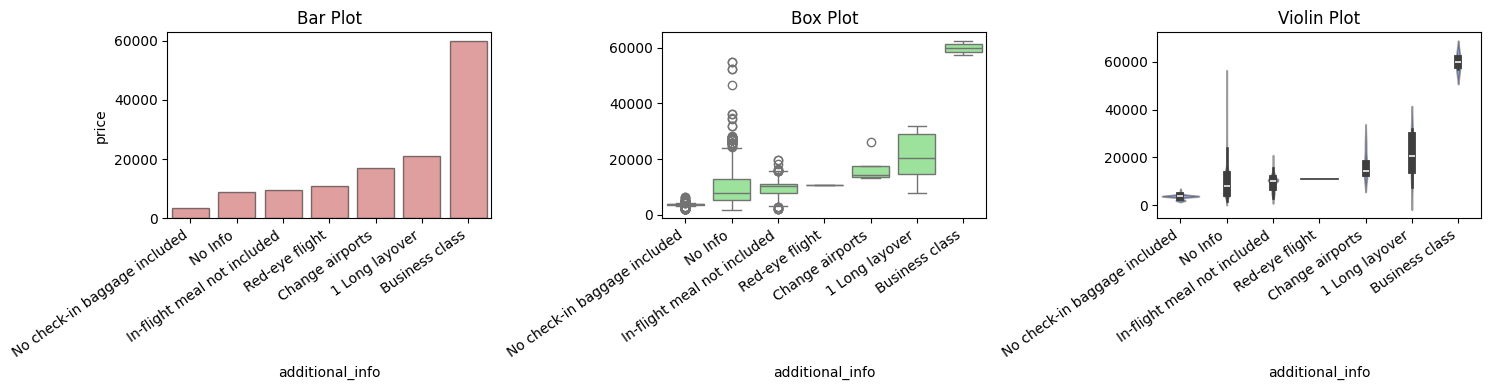

In [104]:
eda_helper_functions.num_cat_bivar_plots(train, "price", "additional_info")

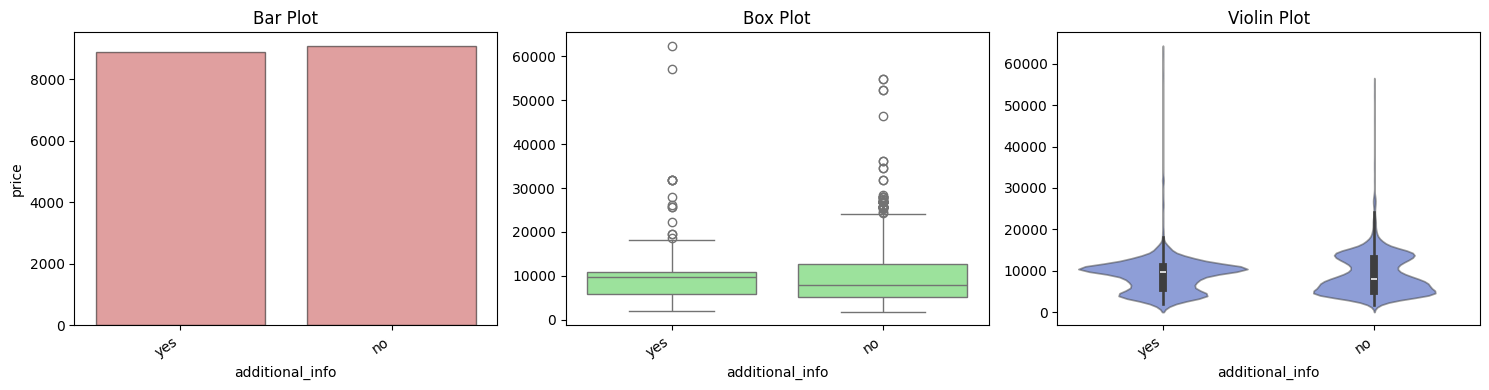

In [106]:
(
    train
    .assign(
        additional_info=(
            train
            .additional_info
            .pipe(lambda ser: np.where(ser.eq("No Info"), "no", "yes"))
        )
    )
    .pipe(eda_helper_functions.num_cat_bivar_plots, "price", "additional_info")
)

- `additional_info` has severly rare categories
- converted it into a binary feature for further analysis